Código de ayuda **para usuarios Windows**:

desde consola en C/hadoop

git clone https://github.com/cdarlint/winutils.git

import os
from pyspark.sql import SparkSession
from pyspark import SparkFiles

# Requiere winutils.exe en HADOOP_HOME\bin (necesario en Windows para addFile)
os.environ["HADOOP_HOME"] = r"C:\hadoop\winutils\hadoop-3.3.6"
os.environ["hadoop.home.dir"] = os.environ["HADOOP_HOME"]
os.environ["PATH"] = os.path.join(os.environ["HADOOP_HOME"], "bin") + ";" + os.environ["PATH"]

# Abrir sesión de Spark (reinicia el kernel antes de ejecutar esta celda para que la JVM arranque con HADOOP_HOME ya definido)
spark = SparkSession.builder.appName("ProcesamientoAvanzado").getOrCreate()

url = "https://raw.githubusercontent.com/gakudo-ai/open-datasets/refs/heads/main/customers-100000.csv"
spark.sparkContext.addFile(url)
df_customers = spark.read.csv(SparkFiles.get("customers-100000.csv"), header=True, inferSchema=True)
df_customers.show()

# COMIENZO DE LA LIBRETA

In [17]:
from pyspark.sql import SparkSession
from pyspark import SparkFiles

# Inicializar la sesión de Spark
spark = SparkSession.builder.appName("ProcesamientoAvanzado").getOrCreate()

In [18]:
# 1. Definimos la URL
url = "https://raw.githubusercontent.com/gakudo-ai/open-datasets/main/customers-100000.csv"

# 2. Spark, a través de su SparkContext: descarga el archivo y lo distribuye en nodos
spark.sparkContext.addFile(url)

# 3. Lectura del archivo usando su nombre original
df_cust = spark.read.csv(SparkFiles.get("customers-100000.csv"), header=True, inferSchema=True)

df_cust.show(5)

+-----+---------------+----------+----------+--------------------+--------------+--------------------+--------------------+--------------------+--------------------+-----------------+--------------------+
|Index|    Customer Id|First Name| Last Name|             Company|          City|             Country|             Phone 1|             Phone 2|               Email|Subscription Date|             Website|
+-----+---------------+----------+----------+--------------------+--------------+--------------------+--------------------+--------------------+--------------------+-----------------+--------------------+
|    1|ffeCAb7AbcB0f07|     Jared|    Jarvis|    Sanchez-Fletcher| Hatfieldshire|             Eritrea|  274.188.8773x41185|001-215-760-4642x969|gabriellehartman@...|       2021-11-11|https://www.mccar...|
|    2|b687FfC4F1600eC|     Marie|    Malone|           Mckay PLC|Robertsonburgh|            Botswana|        283-236-9529| (189)129-8356x63741|kstafford@sexton.com|       2021-05-

In [19]:
# Conocer el tamaño de un DataFrame en PySpark (equivalente a .shape en Pandas)
shape = (df_cust.count(), len(df_cust.columns))

print(f"Filas: {shape[0]}, Columnas: {shape[1]}")

Filas: 100000, Columnas: 12


Manejo de valores nulos

In [20]:
from pyspark.sql.functions import col, coalesce, lit

url = "https://raw.githubusercontent.com/gakudo-ai/open-datasets/main/employees_dataset_with_missing.csv"
spark.sparkContext.addFile(url)

# Cargar el dataset
df_emp = spark.read.csv(SparkFiles.get("employees_dataset_with_missing.csv"), header=True, inferSchema=True)

df_emp.show()

+------------------+-----------------+------------------+-------------------+------------------+
|               age|           income|   education_years|         experience|      credit_score|
+------------------+-----------------+------------------+-------------------+------------------+
|              NULL|70990.33154879004|11.974465175076855|0.46096221061304554| 563.6506395035066|
| 33.61735698828815|63869.50524369153|13.566443987853447|  5.698074946102491| 646.8796511060916|
| 41.47688538100692|50894.45554880261|11.622740237000116|  7.931972332891778| 651.8016872044446|
| 50.23029856408026|40295.94833441639| 13.07611541108288|  19.43843828670095| 697.2630345843405|
|32.658466252766644|60473.34970420385| 8.319155999138644|  12.78276562266879| 513.3141636719174|
|  32.6586304305082|55902.28078132625|14.639881122118815| 3.3225921545005432|  709.256727384733|
| 50.79212815507391|63427.89830041598|14.003616426086673| 12.430181447088184|379.56083683972247|
| 42.67434729152909|59527.5770

In [21]:
# Limpieza y tratamiento de nulos sobre columnas del dataset
df_clean = df_emp.dropna(how="all") \
    .fillna({
        "income": 0.0,
        "credit_score": 300  # Puntuación crediticia por defecto
    }) \
    .withColumn("experience", coalesce(col("experience"), lit(0)))
    # coalesce toma el primer valor no nulo; si 'experience' es nulo, asigna 0

df_clean.show()

+------------------+-----------------+------------------+-------------------+------------------+
|               age|           income|   education_years|         experience|      credit_score|
+------------------+-----------------+------------------+-------------------+------------------+
|              NULL|70990.33154879004|11.974465175076855|0.46096221061304554| 563.6506395035066|
| 33.61735698828815|63869.50524369153|13.566443987853447|  5.698074946102491| 646.8796511060916|
| 41.47688538100692|50894.45554880261|11.622740237000116|  7.931972332891778| 651.8016872044446|
| 50.23029856408026|40295.94833441639| 13.07611541108288|  19.43843828670095| 697.2630345843405|
|32.658466252766644|60473.34970420385| 8.319155999138644|  12.78276562266879| 513.3141636719174|
|  32.6586304305082|55902.28078132625|14.639881122118815| 3.3225921545005432|  709.256727384733|
| 50.79212815507391|63427.89830041598|14.003616426086673| 12.430181447088184|379.56083683972247|
| 42.67434729152909|59527.5770

Limpiar nombres, extraer dominios o unificar formatos son tareas diarias. Se utilizan funciones integradas de `pyspark.sql.functions` para procesar texto a nivel de clúster de nodos, es decir, de forma distribuida.

In [22]:
from pyspark.sql.functions import concat_ws, trim, upper, regexp_replace, split

# Cargamos el dataset de clientes
df_cust = spark.read.csv(SparkFiles.get("customers-100000.csv"), header=True, inferSchema=True)

# Procesamiento de strings complejo
df_strings = df_cust.withColumn(
    "full_name", concat_ws(" ", col("First Name"), col("Last Name"))
).withColumn(
    "email_domain", split(col("Email"), "@").getItem(1)
).withColumn(
    "clean_company", trim(upper(regexp_replace(col("Company"), "[,.]", "")))
)

df_strings.select("full_name", "email_domain", "clean_company").show(5)

+-----------------+-------------------+--------------------+
|        full_name|       email_domain|       clean_company|
+-----------------+-------------------+--------------------+
|     Jared Jarvis|       benjamin.com|    SANCHEZ-FLETCHER|
|     Marie Malone|         sexton.com|           MCKAY PLC|
|   Elijah Barrera|          brown.com|      MARKS AND SONS|
|Sheryl Montgomery|        barrett.com|KIRBY VAUGHN AND ...|
|   Jeremy Houston|jacobs-wallace.info|      LESTER-MANNING|
+-----------------+-------------------+--------------------+
only showing top 5 rows


Procesamiento con series temporales

In [23]:
from pyspark.sql.functions import to_date, year, month, date_format

url = "https://raw.githubusercontent.com/gakudo-ai/open-datasets/main/CTA_-_Ridership_-_Daily_Boarding_Totals.csv"
spark.sparkContext.addFile(url)
df_cta = spark.read.csv(SparkFiles.get("CTA_-_Ridership_-_Daily_Boarding_Totals.csv"), header=True, inferSchema=True)

# Transformación de fechas sobre la columna real 'service_date'
df_dates = df_cta.withColumn(
    "parsed_date", to_date(col("service_date"), "MM/dd/yyyy")
).withColumn(
    "year", year(col("parsed_date"))
).withColumn(
    "month_name", date_format(col("parsed_date"), "MMMM")
).filter(col("year") >= 2018) # Filtramos años recientes

df_dates.select("service_date", "parsed_date", "year", "month_name").show(5)

+------------+-----------+----+----------+
|service_date|parsed_date|year|month_name|
+------------+-----------+----+----------+
|  03/01/2018| 2018-03-01|2018|     March|
|  02/04/2018| 2018-02-04|2018|  February|
|  03/19/2018| 2018-03-19|2018|     March|
|  03/31/2018| 2018-03-31|2018|     March|
|  01/01/2018| 2018-01-01|2018|   January|
+------------+-----------+----+----------+
only showing top 5 rows


Agregaciones avanzadas

In [24]:
from pyspark.sql.window import Window
from pyspark.sql.functions import sum as spark_sum, rank, desc

# 1. Agregación múltiple (usando la columna real 'total_rides')
df_agg = df_dates.groupBy("year", "month_name").agg(
    spark_sum("total_rides").alias("monthly_rides")
)

# 2. Window Function: Los 3 meses con más viajes de CADA AÑO
window_spec = Window.partitionBy("year").orderBy(desc("monthly_rides"))

# Asignamos un ranking y filtramos el top 3
df_top3 = df_agg.withColumn("ranking", rank().over(window_spec)) \
                .filter(col("ranking") <= 3)

df_top3.show(10)

+----+----------+-------------+-------+
|year|month_name|monthly_rides|ranking|
+----+----------+-------------+-------+
|2018|   October|     44288281|      1|
|2018|       May|     41086176|      2|
|2018|    August|     40573322|      3|
|2019|   October|     42383146|      1|
|2019|       May|     40351838|      2|
|2019| September|     40035897|      3|
|2020|   January|     36663540|      1|
|2020|  February|     35328884|      2|
|2020|     March|     23135120|      3|
|2021| September|     21047016|      1|
+----+----------+-------------+-------+
only showing top 10 rows


In [25]:
spark.stop()

PARTE 2

**Analisis Exploratorio (EDA)**

Inicialización de sesión Spark

In [26]:
from pyspark.sql import SparkSession
from pyspark import SparkFiles

# Inicializar sesión
spark = SparkSession.builder.appName("EDA_Basico").getOrCreate()

# Carga del dataset de empleados
url = "https://raw.githubusercontent.com/gakudo-ai/open-datasets/main/employees_dataset_with_missing.csv"
spark.sparkContext.addFile(url)

df_eda = spark.read.csv(SparkFiles.get("employees_dataset_with_missing.csv"), header=True, inferSchema=True)
df_eda.show(5)

+------------------+-----------------+------------------+-------------------+-----------------+
|               age|           income|   education_years|         experience|     credit_score|
+------------------+-----------------+------------------+-------------------+-----------------+
|              NULL|70990.33154879004|11.974465175076855|0.46096221061304554|563.6506395035066|
| 33.61735698828815|63869.50524369153|13.566443987853447|  5.698074946102491|646.8796511060916|
| 41.47688538100692|50894.45554880261|11.622740237000116|  7.931972332891778|651.8016872044446|
| 50.23029856408026|40295.94833441639| 13.07611541108288|  19.43843828670095|697.2630345843405|
|32.658466252766644|60473.34970420385| 8.319155999138644|  12.78276562266879|513.3141636719174|
+------------------+-----------------+------------------+-------------------+-----------------+
only showing top 5 rows


In [27]:
# Inspección del esquema/estructura del dataset
# Mostrar el tipo de dato de cada columna y su jerarquía
df_eda.printSchema()

# Recuento total de filas para dimensionar el volumen de datos
print(f"Total de registros a analizar: {df_eda.count()}")

root
 |-- age: double (nullable = true)
 |-- income: double (nullable = true)
 |-- education_years: double (nullable = true)
 |-- experience: double (nullable = true)
 |-- credit_score: double (nullable = true)

Total de registros a analizar: 1000


In [28]:
# Resumen estadístico de las columnas numéricas principales
df_eda.select("age", "income", "experience", "credit_score").summary().show()

+-------+------------------+------------------+------------------+------------------+
|summary|               age|            income|        experience|      credit_score|
+-------+------------------+------------------+------------------+------------------+
|  count|               884|               851|               873|              1000|
|   mean| 35.27990294811745| 51060.01732721878| 10.00990610503992| 645.0726360597142|
| stddev| 9.842874379487004|14941.524310087243| 5.164959261070912| 99.23802133010426|
|    min|2.5873265993092716| 5894.170480035798| -4.64724345001134|332.32961868039996|
|    25%|28.751814223043212|40882.670193583515| 6.380048341286955| 581.3720864244915|
|    50%| 35.26885838994531| 51017.83265791105|10.150157395820411| 648.0126364631689|
|    75%| 41.54365656354058|  61052.6584563865|13.435328979294582| 713.7324683023072|
|    max| 73.52731490654722| 97896.61351767291|26.215464847973667| 961.2910201043841|
+-------+------------------+------------------+-------

In [29]:
from pyspark.sql.functions import col, sum as spark_sum, when

# Calcular la cantidad exacta de valores nulos por cada columna
df_nulos = df_eda.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df_eda.columns
])

df_nulos.show()

+---+------+---------------+----------+------------+
|age|income|education_years|experience|credit_score|
+---+------+---------------+----------+------------+
|116|   149|             91|       127|           0|
+---+------+---------------+----------+------------+



In [30]:
from pyspark.sql.functions import round, avg, count

# Agrupamos por franja de edad para detectar tendencias financieras
# Redondeamos la edad a la decena más cercana para crear grupos
# de edad y evaluar cómo varía el ingreso y el score crediticio
# según la franja de edad.
df_tendencias = df_eda.filter(col("age").isNotNull()) \
    .withColumn("franja_edad", round(col("age"), -1)) \
    .groupBy("franja_edad") \
    .agg(
        avg("income").alias("ingreso_medio"),
        avg("credit_score").alias("score_crediticio_medio"),
        count("*").alias("cantidad_empleados")
    ) \
    .orderBy("franja_edad")

df_tendencias.show()

+-----------+------------------+----------------------+------------------+
|franja_edad|     ingreso_medio|score_crediticio_medio|cantidad_empleados|
+-----------+------------------+----------------------+------------------+
|        0.0| 58081.33988669554|     725.9514887486108|                 1|
|       10.0|56307.300978147316|     647.0327497432684|                15|
|       20.0|  52809.1616663739|     640.4526271361744|               113|
|       30.0| 52274.68990381488|     645.6454512178516|               304|
|       40.0| 52026.49493991753|     643.7070550354364|               313|
|       50.0|51154.762879453745|     646.5556587952161|               115|
|       60.0| 46838.81066171808|     632.3633324290007|                21|
|       70.0|  36687.6173329685|     523.9725485114844|                 2|
+-----------+------------------+----------------------+------------------+



**Gráfico de barras:** ingresos promedios por franja de edad

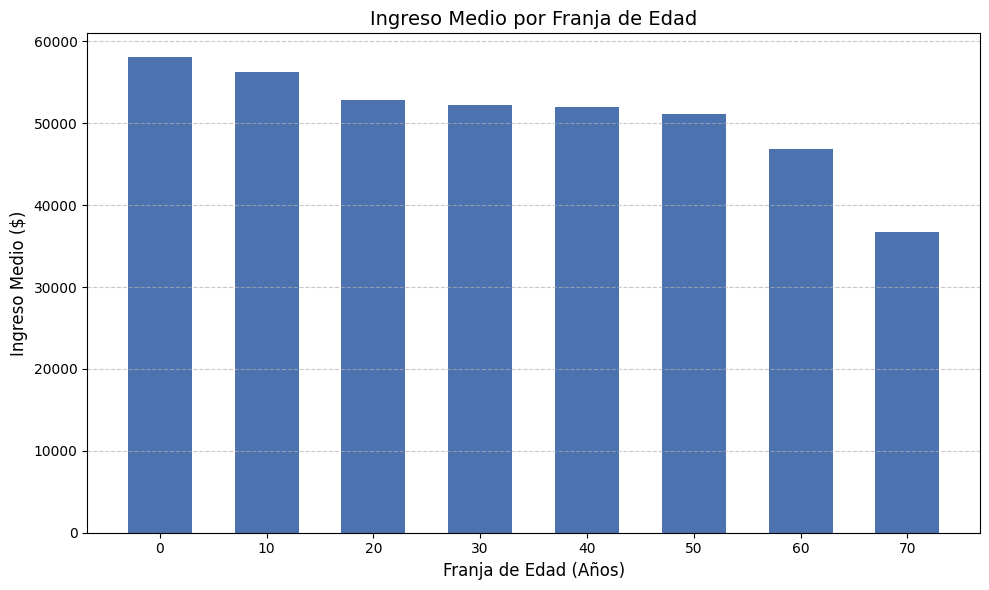

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

# Convertir el DataFrame agrupado de Spark a Pandas
pdf_tendencias = df_tendencias.toPandas()

# Filtrar la fila donde la franja de edad es nula para no ensuciar el gráfico
pdf_tendencias = pdf_tendencias.dropna(subset=['franja_edad'])
pdf_tendencias = pdf_tendencias.sort_values(by='franja_edad')

# Configuración y renderizado del gráfico
plt.figure(figsize=(10, 6))
plt.bar(pdf_tendencias['franja_edad'], pdf_tendencias['ingreso_medio'], color='#4C72B0', width=6)
plt.title('Ingreso Medio por Franja de Edad', fontsize=14)
plt.xlabel('Franja de Edad (Años)', fontsize=12)
plt.ylabel('Ingreso Medio ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Gráfico de dispersión:** relación entre experiencia e ingresos

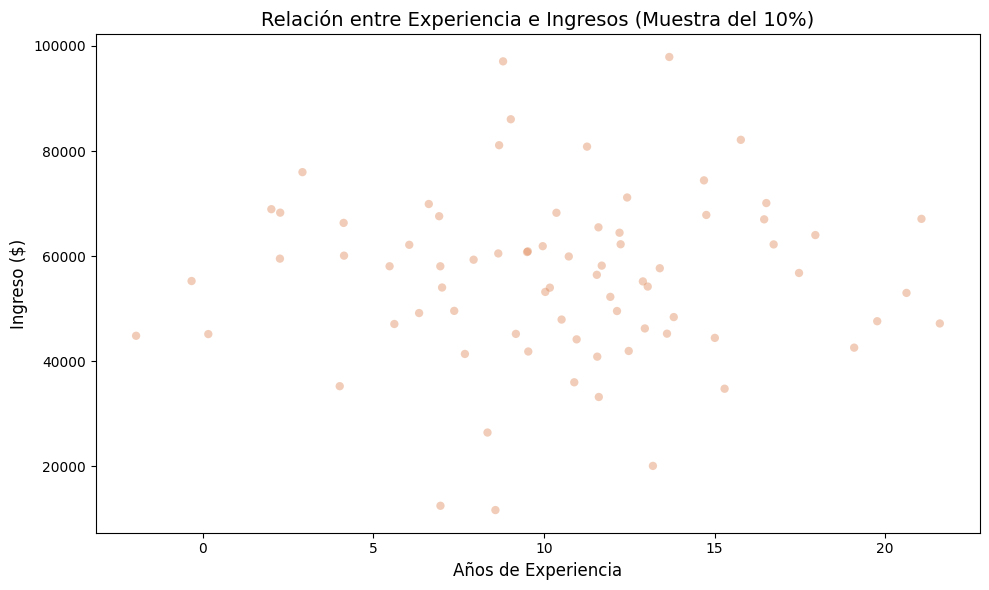

In [32]:
# 1. Spark: Limpiar nulos y extraer una muestra aleatoria del 10% (0.1)
df_muestra = df_eda.select("experience", "income").dropna().sample(withReplacement=False, fraction=0.1, seed=42)

# 2. Convertir solo esa pequeña muestra a Pandas
pdf_muestra = df_muestra.toPandas()

# 3. Matplotlib: Renderizar el gráfico
plt.figure(figsize=(10, 6))
plt.scatter(pdf_muestra['experience'], pdf_muestra['income'], alpha=0.4, color='#DD8452', edgecolors='none')
plt.title('Relación entre Experiencia e Ingresos (Muestra del 10%)', fontsize=14)
plt.xlabel('Años de Experiencia', fontsize=12)
plt.ylabel('Ingreso ($)', fontsize=12)
plt.tight_layout()
plt.show()

**Los análisis realizados han mostrado una realidad un tanto absurda pero no tan rara de encontrar**

Los bebés (franja de 0 años) y los niños-preadolescentes (franja de 10 años) aparecen con los ingresos medios más altos, superando los 50,000 dólares. Para colmo, la tendencia muestra que el salario cae drásticamente conforme los empleados envejecen, yendo en contra de cualquier lógica.

Estamos ante un ejemplo del valor del EDA como herramientas no solo para explorar y entender los datos, sino también para "cazar" problemas. Y este dataset en abierto es conocido por contener datos sucios (dirty data). Se asume en el mismo la existencia de errores de captura donde la edad se dejó en 0 'por defecto', existen posibles valores atípicos, o hay registros nulos que, al forzar la agrupación en grupos de edad, matemáticamente desvían resultados de agregaciones y hacen que los ingresos promedio se vean sesgados.

**SOLUCIÓN:** pasar por un filtrado de edades ilógicas, ingresos nulos, y solo tras esto, realizar el agrupamiento

In [33]:
from pyspark.sql.functions import col, round, avg, count

# 1. Filtramos edades ilógicas (ej. menores de 18 o mayores de 80) e ingresos nulos
df_filtrado = df_eda.filter(
    (col("age") >= 18) &
    (col("age") <= 80) &
    (col("income").isNotNull()) &
    (col("income") > 0)
)

# 2. Volvemos a agrupar por franja de edad sobre los datos limpios
df_tendencias_real = df_filtrado.withColumn("franja_edad", round(col("age"), -1)) \
    .groupBy("franja_edad") \
    .agg(
        avg("income").alias("ingreso_medio"),
        count("*").alias("cantidad_empleados")
    ) \
    .orderBy("franja_edad")

# Mostramos el resultado numérico para validar la corrección
df_tendencias_real.show()

+-----------+------------------+------------------+
|franja_edad|     ingreso_medio|cantidad_empleados|
+-----------+------------------+------------------+
|       20.0| 53456.70866003753|                81|
|       30.0| 52274.68990381488|               251|
|       40.0| 52026.49493991753|               262|
|       50.0|51154.762879453745|                97|
|       60.0| 46838.81066171808|                17|
|       70.0|  36687.6173329685|                 1|
+-----------+------------------+------------------+



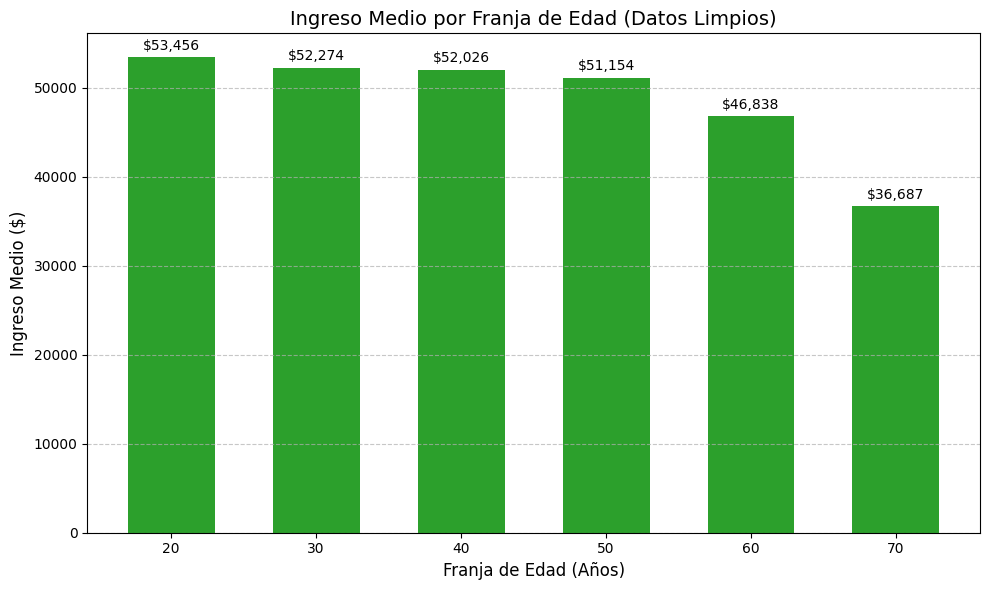

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Convertimos el DataFrame limpio y agrupado de Spark a Pandas
pdf_tendencias_real = df_tendencias_real.toPandas()

# 2. Aseguramos que los datos estén ordenados cronológicamente por edad
pdf_tendencias_real = pdf_tendencias_real.sort_values(by='franja_edad')

# 3. Configuración y renderizado del gráfico
plt.figure(figsize=(10, 6))
# Usamos un color verde para diferenciarlo visualmente del gráfico erróneo anterior
barras = plt.bar(pdf_tendencias_real['franja_edad'], pdf_tendencias_real['ingreso_medio'], color='#2CA02C', width=6)

plt.title('Ingreso Medio por Franja de Edad (Datos Limpios)', fontsize=14)
plt.xlabel('Franja de Edad (Años)', fontsize=12)
plt.ylabel('Ingreso Medio ($)', fontsize=12)

# 4. Añadimos las etiquetas de texto sobre cada barra para ver la cifra exacta
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura + 500,
             f'${int(altura):,}',
             ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Parece persistir el problema de ingresos medios que decrecen conla edad y experiencia. Por tanto, es posible que se trate de datos generados sintéticamente que no necesariamente obedezcan patrones propios de la vida real.

Realicemos un análisis de correlación de Pearson para confirmarlo:

In [35]:
from pyspark.sql.functions import corr

# Calculamos la correlación estadística entre la edad y los ingresos
df_correlacion = df_filtrado.select(
    corr("age", "income").alias("correlacion_edad_ingresos")
)

# Extraemos el valor para mostrarlo con un formato legible
valor_corr = df_correlacion.collect()[0]["correlacion_edad_ingresos"]

print(f"Coeficiente de correlación de Pearson (Edad vs Ingresos): {valor_corr:.4f}")

Coeficiente de correlación de Pearson (Edad vs Ingresos): -0.0425
